-Graphics-   -Graphics-   -Graphics-   -Graphics-
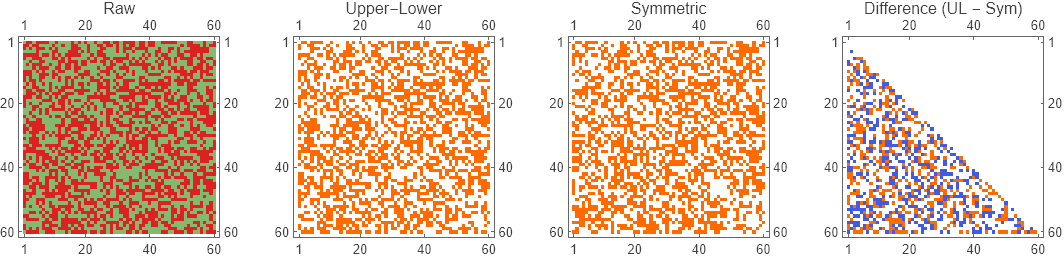

In [13]:
g = ExampleData[{"NetworkGraph", "ZacharyKarateClub"}];

FindGraphCommunities[g];
(* CommunityGraphPlot[g, %] *)
(* CommunityGraphPlot[g, Method ->"Hierarchical"] *)

SeedRandom[]; 
rawAdj = RandomInteger[{0, 1}, {60, 60}];
rawPlot = MatrixPlot[rawAdj,
  PlotLabel -> "Raw",
  ColorFunction -> "Rainbow"
  ];
ulAdj = UpperTriangularize[rawAdj, 1] + LowerTriangularize[rawAdj, -1];
symAdj = UpperTriangularize[rawAdj, 1] + Transpose[UpperTriangularize[rawAdj, 1]];
ulPlot = MatrixPlot[ulAdj, 
  PlotLabel -> "Upper-Lower"
  ];
symPlot = MatrixPlot[symAdj,
  PlotLabel -> "Symmetric"
  ];
diffPlot = MatrixPlot[ulAdj - symAdj,
  PlotLabel -> "Difference (UL - Sym)"
  ];
Grid[{
  {rawPlot, ulPlot, symPlot, diffPlot}
}, Spacings -> {2, 2}]

Graph[<60>, <872>]
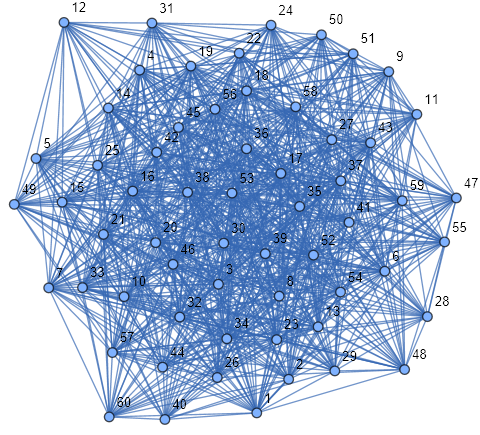

In [16]:
symGraph = Graph[AdjacencyGraph[symAdj,  VertexLabels -> "Name", DirectedEdges -> False]]

-Graphics-
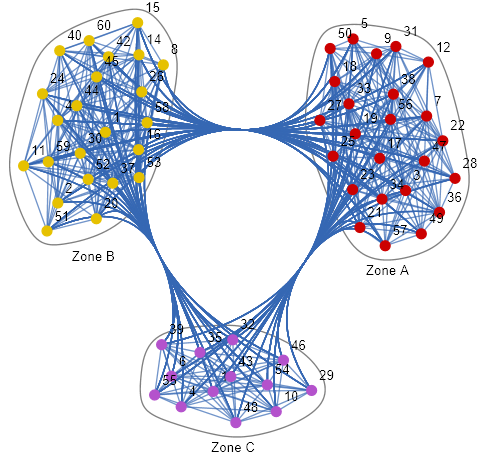

In [24]:
symCommunities = FindGraphCommunities[symGraph];
indexToLetters[i_] := Module[{n = i, s = ""}, 
    While[n > 0, s = FromCharacterCode[65 + Mod[n - 1, 26]] <> s; n = Quotient[n - 1, 26]]; s];
symLabels = Table["Zone " <> indexToLetters[i], {i, Length[symCommunities]}];
CommunityGraphPlot[symGraph, CommunityLabels -> Placed[symLabels, Below]]

-Graphics-
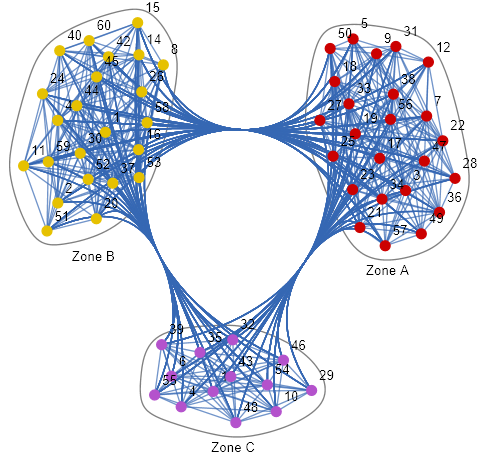

In [25]:
CommunityGraphPlot[symGraph, Method -> "LabelPropagation", CommunityLabels -> Placed[symLabels, Below]]

{16.2351, 13.1839, 14.3558, 11.1998, 14.4886, 13.5525, 14.6973, 15.1733, 12.5791, 
 
>   13.623, 10.1161, 7.20363, 17.317, 15.0539, 13.3699, 18.594, 17.2687, 17.6395, 
 
>   17.9299, 10.9964, 12.8269, 13.5815, 17.5504, 10.7137, 16.0102, 15.7382, 17.9338, 
 
>   8.26492, 14.0104, 24.3819, 10.2115, 16.7099, 14.2651, 19.4483, 21.4404, 11.8756, 
 
>   17.5413, 21.5864, 22.1834, 8.57376, 19.4262, 17.2653, 17.8528, 10.6194, 15.9903, 
 
>   19.9492, 10.7099, 10.3333, 11.0168, 10.5265, 9.60708, 16.9805, 22.5806, 16.1734, 
 
>   12.3357, 18.6729, 15.5805, 18.0757, 14.9293, 9.94918}
Graph[<60>, <872>]
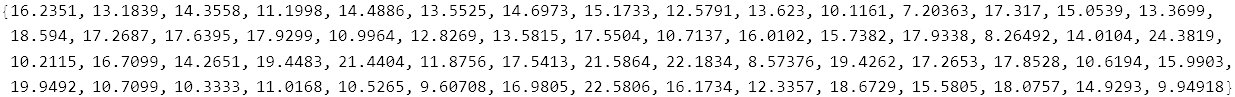
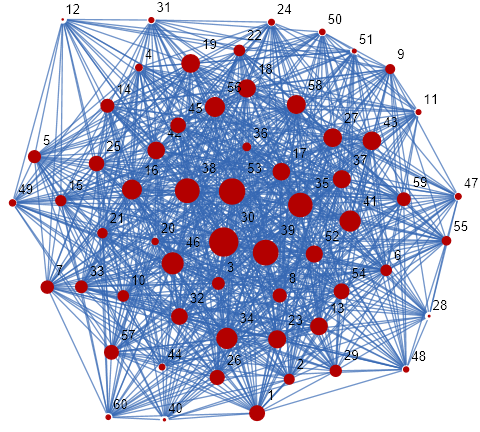

In [17]:
BetweennessCentrality[symGraph]
HighlightGraph[symGraph,
  VertexList[symGraph], VertexSize -> Thread[VertexList[symGraph] -> Rescale[%]]]

-Graphics-
-Graphics-
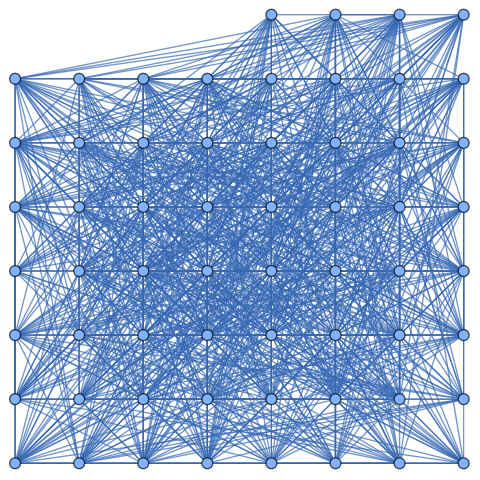
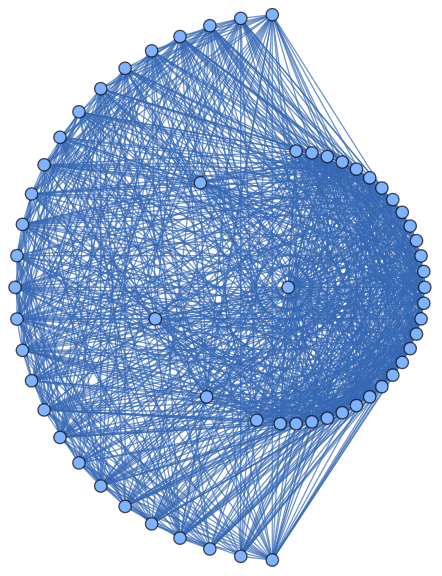

In [78]:
GraphPlot[symAdj, 
    (* Method -> "LabelPropagation", *)
    (* CommunityLabels -> Placed[symLabels, Below], *)
    GraphLayout -> {"DiscreteSpiralEmbedding", "OptimalOrder" -> False}]

GraphPlot[symAdj,
    GraphLayout -> "RadialEmbedding"
    ]